# Thermocouple Reading Uncertainty

This notebook estimates the measured thermocouple readout noise from stationary leak-test data, then combines it with the calibration-anchor uncertainty model to give a recommended instantaneous `1σ` uncertainty for each calibrated TC reading.

The electronic/readout noise estimate uses pump-off, valve-closed leak-test sections. Slow room drift is removed with a centered 300 s rolling median before computing residual scatter. The final recommendation uses the median observed residual noise across stationary sections.

The `THM` and `THI` heat-exchanger channels also receive an assigned extrapolation model term below their `-35.04 C` calibration anchor:

\[
    u_{\mathrm{model},K}(T)=0.01\max(0, -35.04 - T).
\]

All uncertainties in this notebook are standard `1σ` uncertainties unless the `U95` column is explicitly shown.

In [1]:
from pathlib import Path
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import orca.logbook as orca_logbook

warnings.filterwarnings(
    'ignore',
    message='FigureCanvasAgg is non-interactive, and thus cannot be shown',
    category=UserWarning,
)

orca_logbook = importlib.reload(orca_logbook)

NB_PATH = Path.cwd()
REPO_ROOT = NB_PATH
for candidate in [NB_PATH, *NB_PATH.parents]:
    if (candidate / 'data').exists() and (candidate / 'analysis').exists():
        REPO_ROOT = candidate
        break

RAW_LEAK_DIR = REPO_ROOT / 'data' / 'raw' / 'leak_test'
APR20_CAL_LOG = REPO_ROOT / 'data' / 'raw' / 'calibration' / 'log_20260420_111545.csv'
TC_CALIBRATION_PATH = REPO_ROOT / 'data' / 'processed' / 'calibration' / 'TC_calibration_20260420.csv'

TC_ORDER = ['TTEST', 'TFO', 'TTI', 'TTO', 'TMI', 'THM', 'THI']
TC_COLUMNS = [f'{tag}_C' for tag in TC_ORDER]
TC_TYPES = {'TTEST': 'T', 'TFO': 'T', 'TTI': 'T', 'TTO': 'T', 'TMI': 'T', 'THM': 'K', 'THI': 'K'}

ROOM_C = 20.2778
LN2_C = -195.8
TYPE_K_LOW_C = -35.04
U_ROOM_C = 0.058
U_LN2_C = 0.049
U_TYPE_K_LOW_C = 0.060
ROLLING_TREND_WINDOW_S = 300.0
MIN_SECTION_SAMPLES = 50
MIN_SECTION_DURATION_S = 300.0

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print(f'Repo root: {REPO_ROOT}')
print(f'Leak-test raw logs: {RAW_LEAK_DIR}')
print(f'Active TC calibration: {TC_CALIBRATION_PATH}')

Repo root: /home/aamy/Documents/hfe-system
Leak-test raw logs: /home/aamy/Documents/hfe-system/data/raw/leak_test
Active TC calibration: /home/aamy/Documents/hfe-system/data/processed/calibration/TC_calibration_20260420.csv


## Methods

For each leak-test log, the notebook reads the TC columns through the same analysis helpers used elsewhere in the repo:

- pre-fix Type-T logs use the legacy K-to-T reconstruction path;
- post-fix logs use the active affine calibration table in memory;
- stationary samples are selected with pump command `0%` and valve closed.

For each channel in each eligible stationary section, the noise residual is

\[
    r_j(t)=T_{\mathrm{cal},j}(t)-\mathrm{rolling\ median}_{300\,\mathrm{s}}[T_{\mathrm{cal},j}(t)].
\]

The per-section noise estimate is the robust `MAD-to-sigma` scatter of `r_j`. Whole-log raw scatter is retained as a diagnostic because it includes real room drift and should be larger than the residual noise.

In [2]:
def load_tc_log_for_noise(path: Path) -> pd.DataFrame:
    data = orca_logbook.read_tc_calibrated_csv(path, calibration_path=TC_CALIBRATION_PATH, preserve_raw=True)
    if data.attrs.get('tc_calibration_reason') == 'legacy_wrong_type_deferred':
        data, note = orca_logbook.apply_legacy_tc_correction(
            data,
            log_path=path,
            flow_reference_column='fluid_temperature_c',
        )
        data.attrs['noise_loader_note'] = note
    data = orca_logbook.canonicalize_tc_columns(data)
    data['time_s'] = pd.to_numeric(data['time_s'], errors='coerce')
    for column in [*TC_COLUMNS, 'pump_cmd_pct', 'valve', 'fluid_temperature_c']:
        if column in data.columns:
            data[column] = pd.to_numeric(data[column], errors='coerce')
    data = data.dropna(subset=['time_s']).sort_values('time_s').reset_index(drop=True)
    return data


def rolling_median_residual(time_s: pd.Series, values: pd.Series, window_s: float = ROLLING_TREND_WINDOW_S) -> pd.DataFrame:
    series = pd.Series(
        pd.to_numeric(values, errors='coerce').to_numpy(float),
        index=pd.to_timedelta(pd.to_numeric(time_s, errors='coerce').to_numpy(float), unit='s'),
    ).sort_index()
    trend = series.rolling(f'{window_s:.0f}s', center=True, min_periods=10).median()
    residual = series - trend
    return pd.DataFrame({
        'time_s': series.index.total_seconds(),
        'value_C': series.to_numpy(float),
        'trend_C': trend.to_numpy(float),
        'residual_C': residual.to_numpy(float),
    }).dropna(subset=['residual_C'])


def robust_sigma(series: pd.Series | np.ndarray) -> float:
    values = pd.to_numeric(pd.Series(series), errors='coerce').dropna().to_numpy(float)
    if len(values) < 2:
        return np.nan
    return float(1.4826 * np.nanmedian(np.abs(values - np.nanmedian(values))))


def slope_c_per_hour(time_s: pd.Series, values: pd.Series) -> float:
    x = pd.to_numeric(time_s, errors='coerce').to_numpy(float)
    y = pd.to_numeric(values, errors='coerce').to_numpy(float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 20:
        return np.nan
    return float(np.polyfit((x[mask] - x[mask][0]) / 3600.0, y[mask], 1)[0])


def stationary_mask(frame: pd.DataFrame) -> pd.Series:
    pump = pd.to_numeric(frame.get('pump_cmd_pct', 0.0), errors='coerce').fillna(0.0)
    valve = pd.to_numeric(frame.get('valve', 0.0), errors='coerce').fillna(0.0)
    return pump.abs().le(0.1) & valve.abs().le(0.1)

In [3]:
section_rows = []
residual_rows = []
example_payload = None

for path in sorted(RAW_LEAK_DIR.glob('*.csv')):
    data = load_tc_log_for_noise(path)
    mask = stationary_mask(data)
    valid_columns = [column for column in orca_logbook.connected_tc_columns(data) if column in TC_COLUMNS]
    loader_reason = data.attrs.get('tc_calibration_reason', '')
    legacy_applied = bool(data.attrs.get('legacy_tc_correction_applied', False))

    for column in valid_columns:
        tag = column.removesuffix('_C')
        section = data.loc[mask & data[column].notna(), ['time_s', column]].copy()
        if len(section) < MIN_SECTION_SAMPLES:
            continue
        duration_s = float(section['time_s'].iloc[-1] - section['time_s'].iloc[0])
        if duration_s < MIN_SECTION_DURATION_S:
            continue

        residual_frame = rolling_median_residual(section['time_s'], section[column])
        if len(residual_frame) < MIN_SECTION_SAMPLES:
            continue

        residual_sigma_c = robust_sigma(residual_frame['residual_C'])
        residual_std_c = float(residual_frame['residual_C'].std(ddof=1))
        raw_std_c = float(section[column].std(ddof=1))
        drift_c_per_h = slope_c_per_hour(section['time_s'], section[column])

        section_rows.append({
            'source_log': path.name,
            'TC': tag,
            'type': TC_TYPES.get(tag, ''),
            'samples': int(len(section)),
            'duration_h': duration_s / 3600.0,
            'mean_C': float(section[column].mean()),
            'raw_std_C': raw_std_c,
            'residual_std_C': residual_std_c,
            'residual_mad_sigma_C': residual_sigma_c,
            'drift_C_per_h': drift_c_per_h,
            'loader_reason': loader_reason,
            'legacy_fix_applied': legacy_applied,
        })

        take_resid = residual_frame[['time_s', 'value_C', 'trend_C', 'residual_C']].copy()
        take_resid['source_log'] = path.name
        take_resid['TC'] = tag
        residual_rows.append(take_resid)

        if example_payload is None and tag in {'TFO', 'TTI', 'TTO', 'TMI'} and path.name == 'log_20260420_125040.csv':
            example_payload = (path.name, tag, residual_frame.copy())

section_noise = pd.DataFrame(section_rows)
residuals = pd.concat(residual_rows, ignore_index=True) if residual_rows else pd.DataFrame()

if section_noise.empty:
    raise RuntimeError('No eligible stationary leak-test TC sections were found.')

summary_cols = [
    'source_log', 'TC', 'samples', 'duration_h', 'mean_C', 'raw_std_C',
    'residual_mad_sigma_C', 'residual_std_C', 'drift_C_per_h', 'legacy_fix_applied',
]
display(section_noise.loc[:, summary_cols].round(4))

,source_log,TC,samples,duration_h,mean_C,raw_std_C,residual_mad_sigma_C,residual_std_C,drift_C_per_h,legacy_fix_applied
0,log_20260311_114721.csv,TFO,5890,2.9153,21.0245,0.1735,0.0297,0.0380,-0.1024,True
1,log_20260311_114721.csv,TTI,5890,2.9153,21.0032,0.2064,0.0297,0.0369,-0.1253,True
2,log_20260311_114721.csv,TTO,5890,2.9153,21.0121,0.2014,0.0445,0.0401,-0.1146,True
3,log_20260311_114721.csv,TMI,5890,2.9153,21.0400,0.1358,0.0445,0.0402,-0.0718,True
4,log_20260311_114721.csv,THM,5890,2.9153,20.1425,0.1671,0.0440,0.0380,0.1764,True
...,...,...,...,...,...,...,...,...,...,...
61,tc_log_20260319_115916.csv,TTI,44704,24.0489,20.4690,0.1050,0.0445,0.0380,-0.0046,True
62,tc_log_20260319_115916.csv,TTO,44704,24.0489,20.4671,0.1017,0.0445,0.0385,-0.0039,True
63,tc_log_20260319_115916.csv,TMI,44704,24.0489,20.4662,0.0880,0.0445,0.0393,-0.0052,True
64,tc_log_20260319_115916.csv,THM,44704,24.0489,19.7313,0.0844,0.0440,0.0388,-0.0069,True


The full-section raw standard deviations are intentionally shown alongside the residual noise. The raw values include real room-temperature drift over multi-hour leak tests; the residual values are the noise estimate after removing slow drift.

In [4]:
noise_summary = (
    section_noise
    .groupby(['TC', 'type'], as_index=False)
    .agg(
        sections=('source_log', 'count'),
        total_samples=('samples', 'sum'),
        median_mean_C=('mean_C', 'median'),
        median_raw_std_C=('raw_std_C', 'median'),
        median_residual_noise_C=('residual_mad_sigma_C', 'median'),
        p90_residual_noise_C=('residual_mad_sigma_C', lambda s: float(s.quantile(0.90))),
        median_abs_drift_C_per_h=('drift_C_per_h', lambda s: float(s.abs().median())),
    )
)

# TTEST is not a normal stable leak-test channel in these logs, so use the April 20
# room calibration window as its stationary readout-noise estimate.
apr20 = orca_logbook.canonicalize_tc_columns(pd.read_csv(APR20_CAL_LOG, comment='#'))
apr20['time_s'] = pd.to_numeric(apr20['time_s'], errors='coerce')
for column in TC_COLUMNS:
    if column in apr20.columns:
        apr20[column] = pd.to_numeric(apr20[column], errors='coerce')
apr20 = orca_logbook.apply_tc_calibration(apr20, TC_CALIBRATION_PATH, preserve_raw=False)
apr20_room_window = (float(apr20['time_s'].iloc[-1]) - 300.0, float(apr20['time_s'].iloc[-1]))
apr20_room = apr20.loc[apr20['time_s'].between(*apr20_room_window), ['time_s', 'TTEST_C']].dropna()
ttest_resid = rolling_median_residual(apr20_room['time_s'], apr20_room['TTEST_C'])
ttest_noise = robust_sigma(ttest_resid['residual_C'])
if not np.isfinite(ttest_noise):
    ttest_noise = robust_sigma(apr20_room['TTEST_C'])

if not noise_summary['TC'].eq('TTEST').any():
    noise_summary = pd.concat([
        pd.DataFrame([{
            'TC': 'TTEST',
            'type': 'T',
            'sections': 1,
            'total_samples': int(len(apr20_room)),
            'median_mean_C': float(apr20_room['TTEST_C'].mean()),
            'median_raw_std_C': float(apr20_room['TTEST_C'].std(ddof=1)),
            'median_residual_noise_C': float(ttest_noise),
            'p90_residual_noise_C': float(ttest_noise),
            'median_abs_drift_C_per_h': abs(slope_c_per_hour(apr20_room['time_s'], apr20_room['TTEST_C'])),
        }]),
        noise_summary,
    ], ignore_index=True)

noise_summary['TC'] = pd.Categorical(noise_summary['TC'], categories=TC_ORDER, ordered=True)
noise_summary = noise_summary.sort_values('TC').reset_index(drop=True)
noise_summary['recommended_u_noise_C'] = noise_summary['median_residual_noise_C']

display(noise_summary.round(4))

print(f'TTEST noise source: April 20 room calibration window {apr20_room_window[0]:.1f}-{apr20_room_window[1]:.1f} s, n={len(apr20_room)}')

,TC,type,sections,total_samples,median_mean_C,median_raw_std_C,median_residual_noise_C,p90_residual_noise_C,median_abs_drift_C_per_h,recommended_u_noise_C
0,TTEST,T,1,145,20.2774,0.0460,0.0452,0.0452,1.0235,0.0452
1,TFO,T,11,397179,20.3920,0.1604,0.0445,0.0445,0.0147,0.0445
2,TTI,T,11,397179,20.3942,0.1814,0.0444,0.0445,0.0190,0.0444
3,TTO,T,11,397179,20.4423,0.1377,0.0445,0.0445,0.0168,0.0445
4,TMI,T,11,397179,20.4392,0.1358,0.0445,0.0446,0.0194,0.0445
5,THM,K,11,397179,19.7084,0.1604,0.0440,0.0440,0.0154,0.0440
6,THI,K,11,397179,20.9934,0.1711,0.0475,0.0475,0.0213,0.0475


TTEST noise source: April 20 room calibration window 5549.1-5849.1 s, n=145


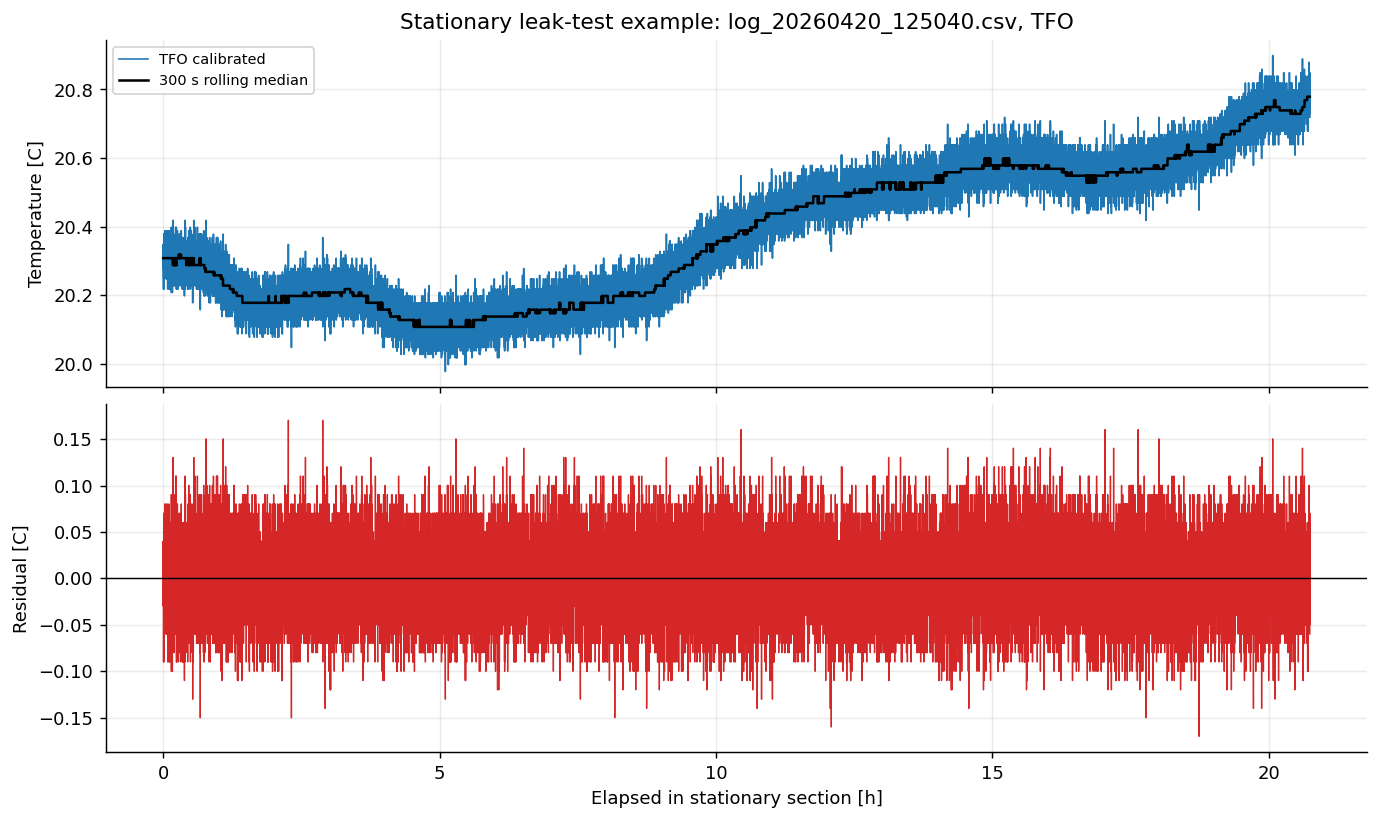

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.2), sharex=True, constrained_layout=True)

if example_payload is None:
    first = residuals.iloc[0]
    example_log, example_tc = str(first['source_log']), str(first['TC'])
    example = residuals[(residuals['source_log'].eq(example_log)) & (residuals['TC'].eq(example_tc))].copy()
else:
    example_log, example_tc, example = example_payload

example = example.copy()
example['elapsed_h'] = (example['time_s'] - float(example['time_s'].iloc[0])) / 3600.0
axes[0].plot(example['elapsed_h'], example['value_C'], lw=0.9, label=f'{example_tc} calibrated')
axes[0].plot(example['elapsed_h'], example['trend_C'], lw=1.4, color='black', label='300 s rolling median')
axes[0].set_ylabel('Temperature [C]')
axes[0].set_title(f'Stationary leak-test example: {example_log}, {example_tc}')
axes[0].legend(fontsize=8)

axes[1].plot(example['elapsed_h'], example['residual_C'], lw=0.75, color='C3')
axes[1].axhline(0.0, color='black', lw=0.8)
axes[1].set_xlabel('Elapsed in stationary section [h]')
axes[1].set_ylabel('Residual [C]')
plt.show()

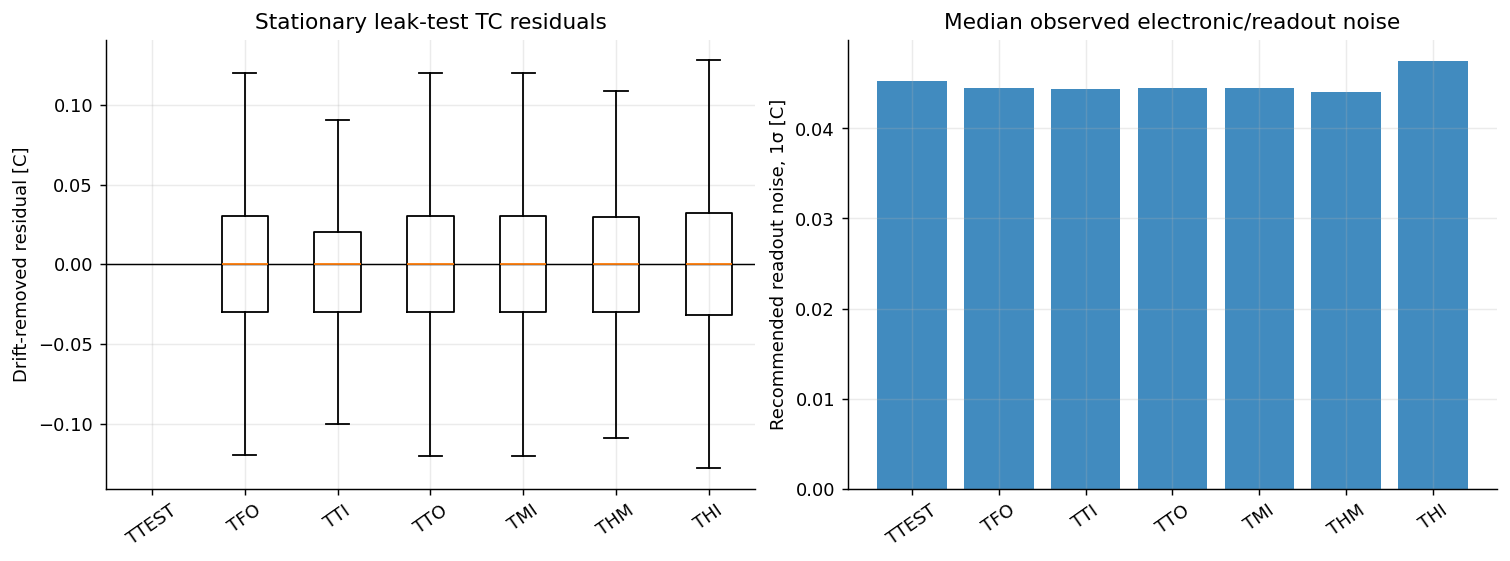

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), constrained_layout=True)

plot_residuals = residuals[residuals['TC'].isin(TC_ORDER)].copy()
plot_residuals['TC'] = pd.Categorical(plot_residuals['TC'], categories=TC_ORDER, ordered=True)
plot_residuals = plot_residuals.sort_values('TC')

box_data = [plot_residuals.loc[plot_residuals['TC'].eq(tag), 'residual_C'].dropna().to_numpy() for tag in TC_ORDER]
axes[0].boxplot(box_data, labels=TC_ORDER, showfliers=False)
axes[0].axhline(0.0, color='black', lw=0.8)
axes[0].set_ylabel('Drift-removed residual [C]')
axes[0].set_title('Stationary leak-test TC residuals')
axes[0].tick_params(axis='x', rotation=35)

axes[1].bar(noise_summary['TC'].astype(str), noise_summary['recommended_u_noise_C'], color='C0', alpha=0.85)
axes[1].set_ylabel('Recommended readout noise, 1σ [C]')
axes[1].set_title('Median observed electronic/readout noise')
axes[1].tick_params(axis='x', rotation=35)
plt.show()

## Calibration and Total Instantaneous Uncertainty

The calibration-anchor uncertainty is propagated with the two-point Lagrange sensitivity coefficients. For an instantaneous reading, the measured readout noise is added directly; it is not divided by the sample count. The `THM` and `THI` model term is an assigned systematic standard uncertainty for using the room-to-`-35.04 C` line below its calibrated interval.

In [7]:
def two_point_anchor_uncertainty(temp_c, lower_c, upper_c, u_lower_c, u_upper_c):
    temp = np.asarray(temp_c, dtype=float)
    denom = upper_c - lower_c
    f_lower = (upper_c - temp) / denom
    f_upper = (temp - lower_c) / denom
    return np.sqrt((f_lower * u_lower_c) ** 2 + (f_upper * u_upper_c) ** 2)


def calibration_uncertainty(tag: str, temp_c):
    if TC_TYPES[tag] == 'K':
        return two_point_anchor_uncertainty(temp_c, TYPE_K_LOW_C, ROOM_C, U_TYPE_K_LOW_C, U_ROOM_C)
    return two_point_anchor_uncertainty(temp_c, LN2_C, ROOM_C, U_LN2_C, U_ROOM_C)


def model_uncertainty(tag: str, temp_c):
    temp = np.asarray(temp_c, dtype=float)
    if tag in {'THM', 'THI'}:
        return 0.01 * np.maximum(0.0, TYPE_K_LOW_C - temp)
    return np.zeros_like(temp, dtype=float)


def noise_uncertainty(tag: str):
    row = noise_summary.loc[noise_summary['TC'].astype(str).eq(tag)]
    if row.empty:
        return np.nan
    return float(row['recommended_u_noise_C'].iloc[0])


def instantaneous_uncertainty(tag: str, temp_c):
    u_cal = calibration_uncertainty(tag, temp_c)
    u_noise = noise_uncertainty(tag)
    u_model = model_uncertainty(tag, temp_c)
    return np.sqrt(u_cal ** 2 + u_noise ** 2 + u_model ** 2)

In [8]:
# Cold minima from logs where the active analysis path can load calibrated TC values.
cold_min = {tag: np.nan for tag in TC_ORDER}
for folder in [REPO_ROOT / 'data' / 'raw' / 'recirculation', REPO_ROOT / 'data' / 'raw' / 'calibration']:
    for path in sorted(folder.glob('*.csv')):
        try:
            frame = orca_logbook.read_tc_calibrated_csv(path, calibration_path=TC_CALIBRATION_PATH, preserve_raw=True)
        except Exception:
            continue
        if frame.attrs.get('tc_calibration_reason') == 'legacy_wrong_type_deferred':
            frame, _ = orca_logbook.apply_legacy_tc_correction(frame, log_path=path, flow_reference_column='fluid_temperature_c')
        for tag in TC_ORDER:
            column = f'{tag}_C'
            if column not in frame.columns:
                continue
            values = pd.to_numeric(frame[column], errors='coerce')
            value = float(values.min()) if values.notna().any() else np.nan
            if np.isfinite(value) and (not np.isfinite(cold_min[tag]) or value < cold_min[tag]):
                cold_min[tag] = value

rows = []
for tag in TC_ORDER:
    temps = [('room', ROOM_C), ('-35 C', -35.0), ('-110 C', -110.0)]
    if np.isfinite(cold_min[tag]):
        temps.append(('observed cold min', cold_min[tag]))
    for label, temp in temps:
        u_cal = float(calibration_uncertainty(tag, temp))
        u_noise = float(noise_uncertainty(tag))
        u_model = float(model_uncertainty(tag, temp))
        u_inst = float(np.sqrt(u_cal ** 2 + u_noise ** 2 + u_model ** 2))
        rows.append({
            'TC': tag,
            'type': TC_TYPES[tag],
            'case': label,
            'T_C': temp,
            'u_cal_C': u_cal,
            'u_noise_C': u_noise,
            'u_model_C': u_model,
            'u_inst_C': u_inst,
            'U95_C': 2.0 * u_inst,
        })

uncertainty_table = pd.DataFrame(rows)
display(uncertainty_table.round(4))

,TC,type,case,T_C,u_cal_C,u_noise_C,u_model_C,u_inst_C,U95_C
0,TTEST,T,room,20.2778,0.0580,0.0452,0.0000,0.0735,0.1471
1,TTEST,T,-35 C,-35.0000,0.0449,0.0452,0.0000,0.0637,0.1275
2,TTEST,T,-110 C,-110.0000,0.0375,0.0452,0.0000,0.0587,0.1174
3,TTEST,T,observed cold min,-196.6182,0.0492,0.0452,0.0000,0.0668,0.1336
4,TFO,T,room,20.2778,0.0580,0.0445,0.0000,0.0731,0.1462
5,TFO,T,-35 C,-35.0000,0.0449,0.0445,0.0000,0.0632,0.1265
6,TFO,T,-110 C,-110.0000,0.0375,0.0445,0.0000,0.0582,0.1163
7,TFO,T,observed cold min,-196.1305,0.0491,0.0445,0.0000,0.0662,0.1325
8,TTI,T,room,20.2778,0.0580,0.0444,0.0000,0.0730,0.1460
9,TTI,T,-35 C,-35.0000,0.0449,0.0444,0.0000,0.0631,0.1263


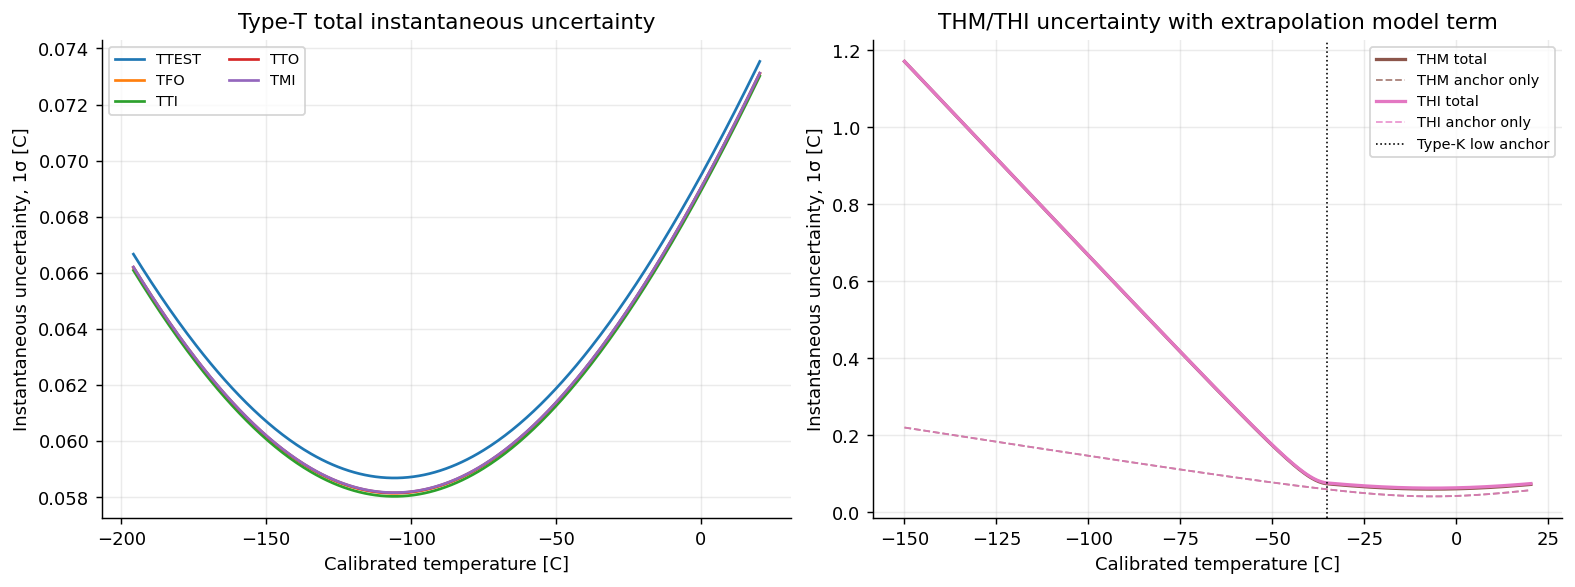

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), constrained_layout=True)

raw_t = np.linspace(LN2_C, ROOM_C, 350)
for tag in ['TTEST', 'TFO', 'TTI', 'TTO', 'TMI']:
    axes[0].plot(raw_t, instantaneous_uncertainty(tag, raw_t), lw=1.5, label=tag)
axes[0].set_xlabel('Calibrated temperature [C]')
axes[0].set_ylabel('Instantaneous uncertainty, 1σ [C]')
axes[0].set_title('Type-T total instantaneous uncertainty')
axes[0].legend(fontsize=8, ncol=2)

hx_t = np.linspace(-150.0, ROOM_C, 350)
for tag, color in [('THM', 'C5'), ('THI', 'C6')]:
    axes[1].plot(hx_t, instantaneous_uncertainty(tag, hx_t), lw=1.8, color=color, label=f'{tag} total')
    axes[1].plot(hx_t, calibration_uncertainty(tag, hx_t), lw=1.0, ls='--', color=color, alpha=0.75, label=f'{tag} anchor only')
axes[1].axvline(TYPE_K_LOW_C, color='black', lw=0.9, ls=':', label='Type-K low anchor')
axes[1].set_xlabel('Calibrated temperature [C]')
axes[1].set_ylabel('Instantaneous uncertainty, 1σ [C]')
axes[1].set_title('THM/THI uncertainty with extrapolation model term')
axes[1].legend(fontsize=8)
plt.show()

## Recommended Values

Use `u_inst_C` for a single calibrated sample at the temperature of interest. Use `U95_C = 2u_inst_C` when a roughly 95% expanded uncertainty is needed.

For averages over a window, keep the same calibration-anchor and model terms, but replace `u_noise_C` by a statistically justified `u_noise_C / sqrt(N_eff)`. The effective sample count should account for time correlation; it is not necessarily the raw number of samples.

## Values to Quote

For any calibrated instantaneous Type-T reading (`TTEST`, `TFO`, `TTI`, `TTO`, `TMI`), use

\[
u_j(T)=\sqrt{
\left[\frac{20.2778-T}{216.0778}(0.049)\right]^2+
\left[\frac{T+195.8}{216.0778}(0.058)\right]^2+
u_{\mathrm{noise},j}^2
}.
\]

In practice, the Type-T total instantaneous standard uncertainty is below `0.08 C` over the calibrated room-to-LN2 range. A concise conservative value to quote is therefore:

\[
    u_{\mathrm{inst}} = 0.1^\circ\mathrm{C}\quad (1\sigma)\qquad\text{for Type-T TCs.}
\]

For the Type-K heat-exchanger readings (`THM`, `THI`), use

\[
u_j(T)=\sqrt{
\left[\frac{20.2778-T}{55.3178}(0.060)\right]^2+
\left[\frac{T+35.04}{55.3178}(0.058)\right]^2+
u_{\mathrm{noise},j}^2+
\left[0.01\max(0,-35.04-T)\right]^2
}.
\]

For `THM` and `THI`, the uncertainty is about `0.08 C` near room to `-35 C`, about `0.77 C` at `-110 C`, and about `1.3 C` at the coldest observed points. Use the temperature-dependent formula rather than a single number for cold HX readings.

For an approximate 95% expanded uncertainty, use `U95 = 2u`.

In [10]:
type_t_quote = noise_summary[noise_summary['type'].eq('T')].loc[:, ['TC', 'recommended_u_noise_C']].copy()
type_t_quote['u_inst_room_C'] = [float(instantaneous_uncertainty(str(tc), ROOM_C)) for tc in type_t_quote['TC']]
type_t_quote['u_inst_-110_C'] = [float(instantaneous_uncertainty(str(tc), -110.0)) for tc in type_t_quote['TC']]
type_t_quote['u_inst_LN2_C'] = [float(instantaneous_uncertainty(str(tc), LN2_C)) for tc in type_t_quote['TC']]
type_t_quote['recommended_quote_C'] = 0.1

hx_quote_rows = []
for tag in ['THM', 'THI']:
    for label, temp in [('room', ROOM_C), ('-35 C', -35.0), ('-110 C', -110.0)]:
        hx_quote_rows.append({
            'TC': tag,
            'case': label,
            'T_C': temp,
            'u_inst_C': float(instantaneous_uncertainty(tag, temp)),
            'U95_C': 2.0 * float(instantaneous_uncertainty(tag, temp)),
        })
hx_quote = pd.DataFrame(hx_quote_rows)

display(Markdown('### Type-T values to quote'))
display(type_t_quote.round(3))
display(Markdown('### THM/THI representative values'))
display(hx_quote.round(3))

### Type-T values to quote

,TC,recommended_u_noise_C,u_inst_room_C,u_inst_-110_C,u_inst_LN2_C,recommended_quote_C
0,TTEST,0.045,0.074,0.059,0.067,0.1
1,TFO,0.044,0.073,0.058,0.066,0.1
2,TTI,0.044,0.073,0.058,0.066,0.1
3,TTO,0.045,0.073,0.058,0.066,0.1
4,TMI,0.045,0.073,0.058,0.066,0.1


### THM/THI representative values

,TC,case,T_C,u_inst_C,U95_C
0,THM,room,20.278,0.073,0.146
1,THM,-35 C,-35.000,0.074,0.149
2,THM,-110 C,-110.000,0.768,1.536
3,THI,room,20.278,0.075,0.150
4,THI,-35 C,-35.000,0.076,0.153
5,THI,-110 C,-110.000,0.768,1.537


In [11]:
recommended = uncertainty_table[uncertainty_table['case'].isin(['room', '-35 C', '-110 C', 'observed cold min'])].copy()
recommended['TC'] = pd.Categorical(recommended['TC'], categories=TC_ORDER, ordered=True)
recommended = recommended.sort_values(['TC', 'case']).reset_index(drop=True)

display(Markdown('### Recommended instantaneous reading uncertainty, standard 1σ'))
display(recommended.round(4))

compact = (
    recommended[recommended['case'].isin(['room', '-110 C', 'observed cold min'])]
    .pivot_table(index=['TC', 'type'], columns='case', values='u_inst_C', aggfunc='first', observed=False)
    .reset_index()
)
display(Markdown('### Compact per-TC values to quote'))
display(compact.round(3))

print('Sanity checks:')
print(f"Median stationary residual noise range: {noise_summary['recommended_u_noise_C'].min():.3f}-{noise_summary['recommended_u_noise_C'].max():.3f} C")
print(f"TTEST April 20 room-window noise: {noise_uncertainty('TTEST'):.3f} C")
print('THM/THI model term at -110 C:', f"{model_uncertainty('THM', -110.0).item():.3f} C")

### Recommended instantaneous reading uncertainty, standard 1σ

,TC,type,case,T_C,u_cal_C,u_noise_C,u_model_C,u_inst_C,U95_C
0,TTEST,T,-110 C,-110.0000,0.0375,0.0452,0.0000,0.0587,0.1174
1,TTEST,T,-35 C,-35.0000,0.0449,0.0452,0.0000,0.0637,0.1275
2,TTEST,T,observed cold min,-196.6182,0.0492,0.0452,0.0000,0.0668,0.1336
3,TTEST,T,room,20.2778,0.0580,0.0452,0.0000,0.0735,0.1471
4,TFO,T,-110 C,-110.0000,0.0375,0.0445,0.0000,0.0582,0.1163
5,TFO,T,-35 C,-35.0000,0.0449,0.0445,0.0000,0.0632,0.1265
6,TFO,T,observed cold min,-196.1305,0.0491,0.0445,0.0000,0.0662,0.1325
7,TFO,T,room,20.2778,0.0580,0.0445,0.0000,0.0731,0.1462
8,TTI,T,-110 C,-110.0000,0.0375,0.0444,0.0000,0.0581,0.1161
9,TTI,T,-35 C,-35.0000,0.0449,0.0444,0.0000,0.0631,0.1263


### Compact per-TC values to quote

case,TC,type,-110 C,observed cold min,room
0,TTEST,T,0.059,0.067,0.074
1,TFO,T,0.058,0.066,0.073
2,TTI,T,0.058,0.066,0.073
3,TTO,T,0.058,0.066,0.073
4,TMI,T,0.058,0.066,0.073
5,THM,K,0.768,1.384,0.073
6,THI,K,0.768,1.248,0.075


Sanity checks:
Median stationary residual noise range: 0.044-0.047 C
TTEST April 20 room-window noise: 0.045 C
THM/THI model term at -110 C: 0.750 C
